In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv(r'insurance.csv')

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
data.shape

(1338, 7)

In [6]:
pd.set_option("display.float_format","{:.2f}".format)

In [7]:
sns.set(style="whitegrid",palette="Set2",font_scale=1.1)

In [8]:
print(data.duplicated().sum())

1


In [9]:
data.drop_duplicates()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.92
1,18,male,33.77,1,no,southeast,1725.55
2,28,male,33.00,3,no,southeast,4449.46
3,33,male,22.70,0,no,northwest,21984.47
4,32,male,28.88,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55
1334,18,female,31.92,0,no,northeast,2205.98
1335,18,female,36.85,0,no,southeast,1629.83
1336,21,female,25.80,0,no,southwest,2007.94


In [10]:
data.shape

(1338, 7)

In [11]:
data.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [12]:
data.describe(include="all")

,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


In [13]:
data.describe()

,age,bmi,children,charges
count,1338.00,1338.00,1338.00,1338.00
mean,39.21,30.66,1.09,13270.42
std,14.05,6.10,1.21,12110.01
min,18.00,15.96,0.00,1121.87
25%,27.00,26.30,0.00,4740.29
50%,39.00,30.40,1.00,9382.03
75%,51.00,34.69,2.00,16639.91
max,64.00,53.13,5.00,63770.43


Text(0.5, 0.98, 'Distribution of numerical features')

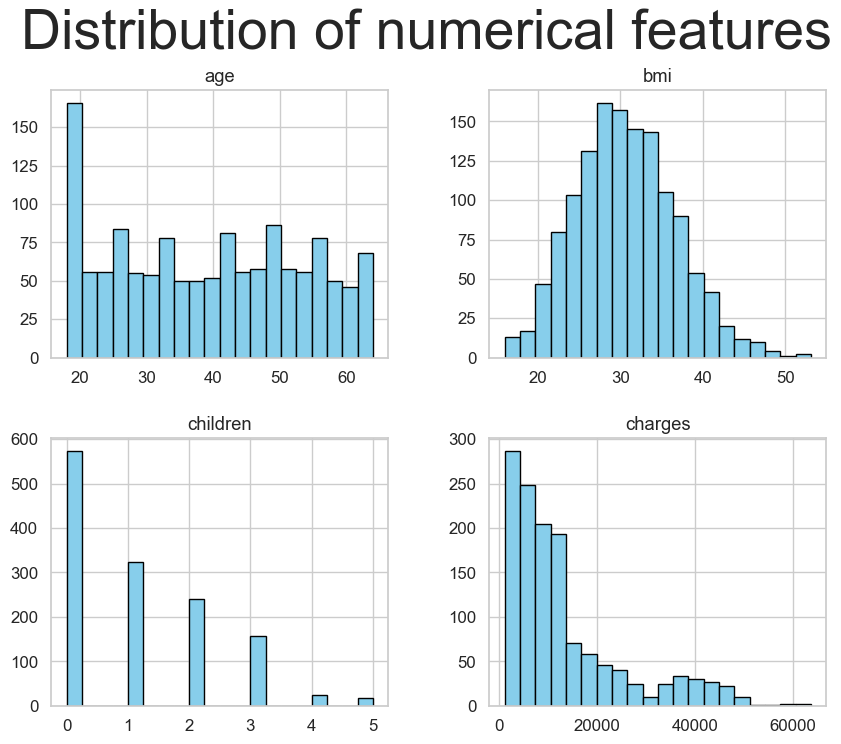

In [14]:
numeric_cols = ["age","bmi","children","charges"]
data[numeric_cols].hist(bins=20,figsize=(10,8),color= "skyblue",edgecolor="black")
plt.suptitle("Distribution of numerical features",fontsize=40)


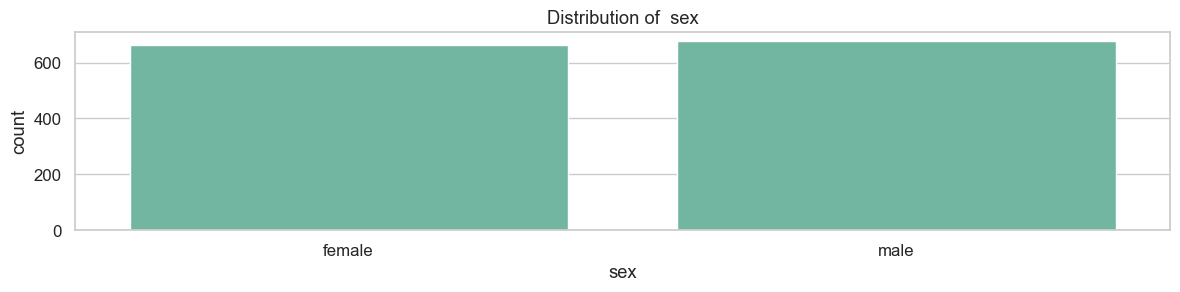

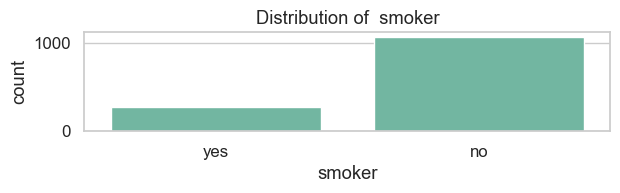

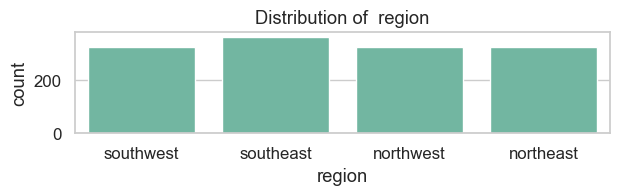

In [15]:
cat_col=["sex","smoker","region"]
plt.figure(figsize=(12,8))
for i,col in enumerate(cat_col,1):
    plt.subplot(3,1,i)
    sns.countplot(data=data,x = col)
    plt.title(f"Distribution of  {col}")
    plt.tight_layout()
    plt.show()

In [16]:
data.groupby(['sex','smoker'])['charges'].mean().round(2)

sex     smoker
female  no        8762.30
        yes      30679.00
male    no        8087.20
        yes      33042.01
Name: charges, dtype: float64

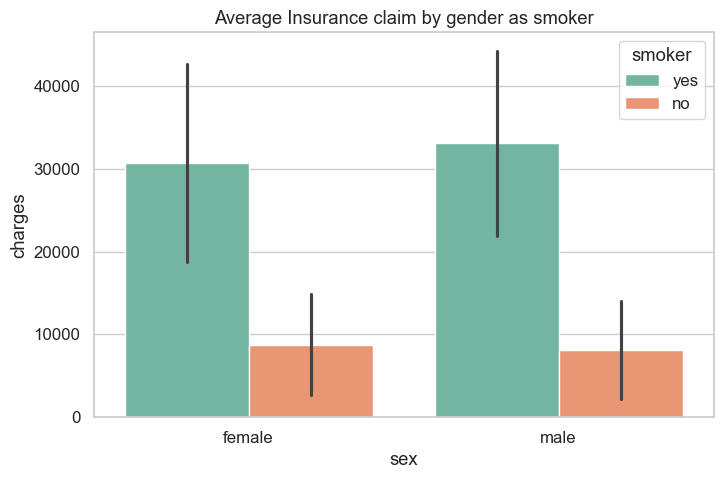

In [17]:
plt.figure(figsize=(8,5))
sns.barplot(data = data,x='sex',y='charges' ,hue='smoker',estimator="mean",errorbar="sd")
plt.title("Average Insurance claim by gender as smoker")
plt.show()


In [18]:
pivot_table = pd.pivot_table(data, values="charges",index="region",columns="smoker",aggfunc="mean")
pivot_table

smoker,no,yes
region,,
northeast,9165.53,29673.54
northwest,8556.46,30192.00
southeast,8032.22,34845.00
southwest,8019.28,32269.06


In [19]:
pivot_table = pd.pivot_table(data,values="charges",index="children",columns="smoker",aggfunc="mean")
pivot_table

smoker,no,yes
children,,
0,7611.79,31341.36
1,8303.11,31822.65
2,9493.09,33844.24
3,9614.52,32724.92
4,12121.34,26532.28
5,8183.85,19023.26


<Axes: >

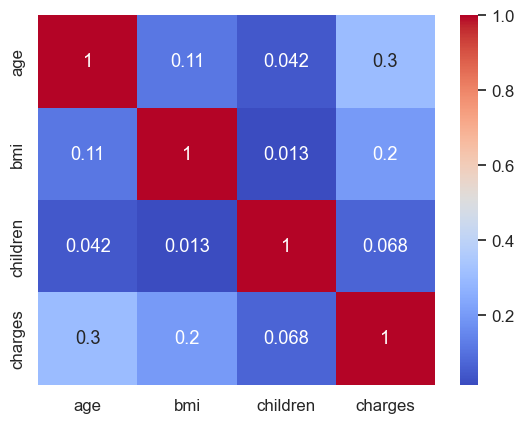

In [20]:
sns.heatmap(data[numeric_cols].corr(),annot=True,cmap="coolwarm")

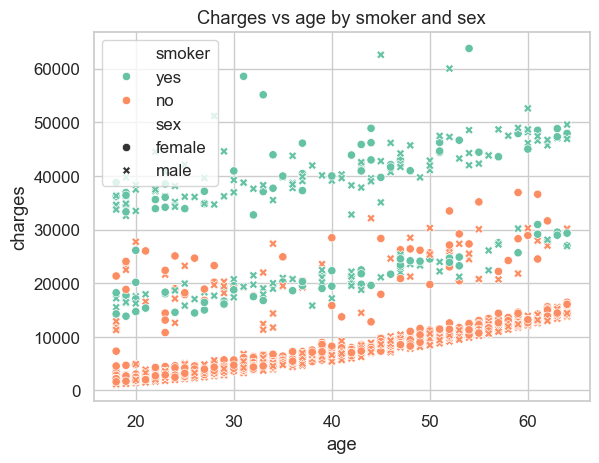

In [21]:
sns.scatterplot(data=data,x='age',y='charges',hue='smoker',style='sex')
plt.title("Charges vs age by smoker and sex")
plt.show()

Text(0.5, 1.0, 'Relationship between BMI & charges')

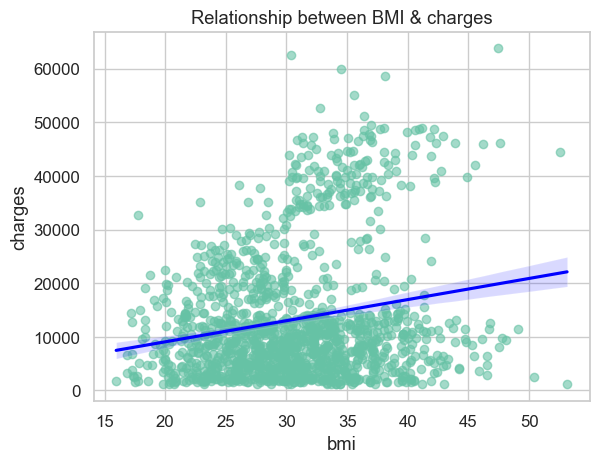

In [22]:
sns.regplot(data=data,x='bmi',y='charges',scatter_kws={"alpha":0.6},line_kws={"color":"blue"})
plt.title("Relationship between BMI & charges")

Text(0.5, 1.0, 'Charges distribution by number of children')

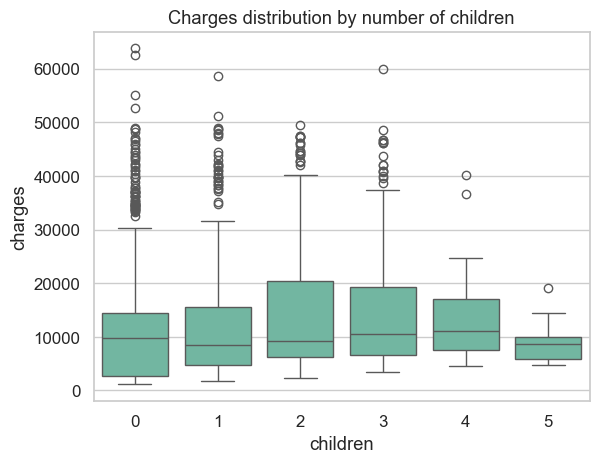

In [23]:
sns.boxplot(data=data,x="children",y="charges")
plt.title("Charges distribution by number of children")

In [24]:
data["age_group"]=pd.cut(data['age'],bins = [0,18,30,45,60,100],labels=["<18","18-30","31-45","46-60","60+"])

In [25]:
data

,age,sex,bmi,children,smoker,region,charges,age_group
0,19,female,27.90,0,yes,southwest,16884.92,18-30
1,18,male,33.77,1,no,southeast,1725.55,<18
2,28,male,33.00,3,no,southeast,4449.46,18-30
3,33,male,22.70,0,no,northwest,21984.47,31-45
4,32,male,28.88,0,no,northwest,3866.86,31-45
...,...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55,46-60
1334,18,female,31.92,0,no,northeast,2205.98,<18
1335,18,female,36.85,0,no,southeast,1629.83,<18
1336,21,female,25.80,0,no,southwest,2007.94,18-30


In [26]:
data["age_group"].value_counts()

age_group
46-60    409
31-45    394
18-30    375
60+       91
<18       69
Name: count, dtype: int64

Text(0.5, 1.0, 'Average claim by a age group')

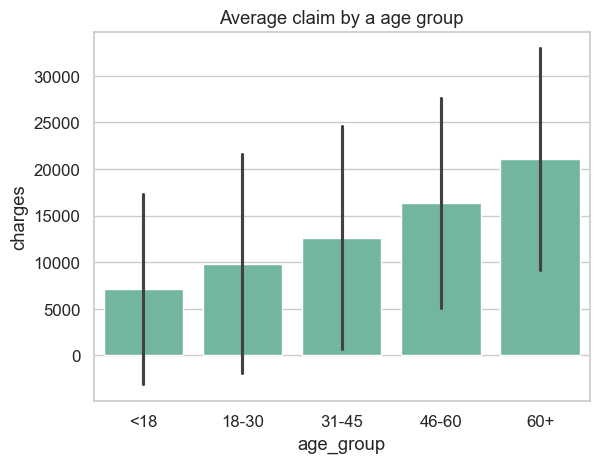

In [27]:
sns.barplot(data=data,x="age_group",y="charges",estimator="mean",errorbar='sd')
plt.title("Average claim by a age group")

In [28]:
data["bmi_category"] = pd.cut(data["bmi"],bins=[0,18.5,24.9,29.9,100],labels=["Underweight", "Normal","Overweight","Obese"])

In [29]:
data

,age,sex,bmi,children,smoker,region,charges,age_group,bmi_category
0,19,female,27.90,0,yes,southwest,16884.92,18-30,Overweight
1,18,male,33.77,1,no,southeast,1725.55,<18,Obese
2,28,male,33.00,3,no,southeast,4449.46,18-30,Obese
3,33,male,22.70,0,no,northwest,21984.47,31-45,Normal
4,32,male,28.88,0,no,northwest,3866.86,31-45,Overweight
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.97,3,no,northwest,10600.55,46-60,Obese
1334,18,female,31.92,0,no,northeast,2205.98,<18,Obese
1335,18,female,36.85,0,no,southeast,1629.83,<18,Obese
1336,21,female,25.80,0,no,southwest,2007.94,18-30,Overweight


In [30]:
data["bmi_category"].value_counts()

bmi_category
Obese          716
Overweight     380
Normal         221
Underweight     21
Name: count, dtype: int64

Text(0.5, 1.0, 'Average claim by bmi_category')

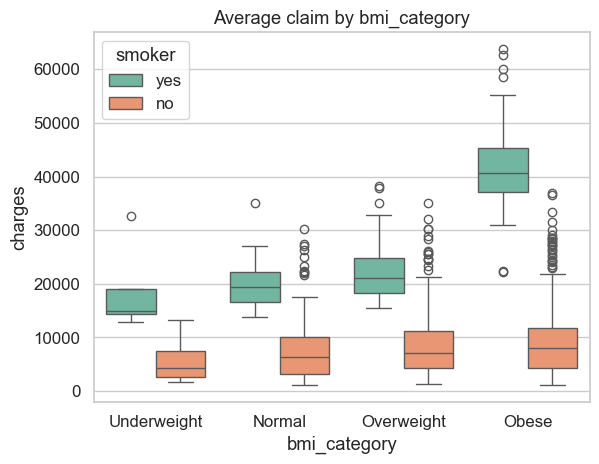

In [31]:
sns.boxplot(data=data,x="bmi_category",y="charges",hue="smoker")
plt.title("Average claim by bmi_category")

In [32]:
region_stats = data.groupby("region").agg(
    smoker_rate = ("smoker", lambda x: (x == "yes").mean() * 100),
    mean_claim = ("charges","mean")
).reset_index()

In [33]:
region_stats

,region,smoker_rate,mean_claim
0,northeast,20.68,13406.38
1,northwest,17.85,12417.58
2,southeast,25.00,14735.41
3,southwest,17.85,12346.94


Text(0.5, 1.0, 'Smoker rate & Sverage claim Per region')

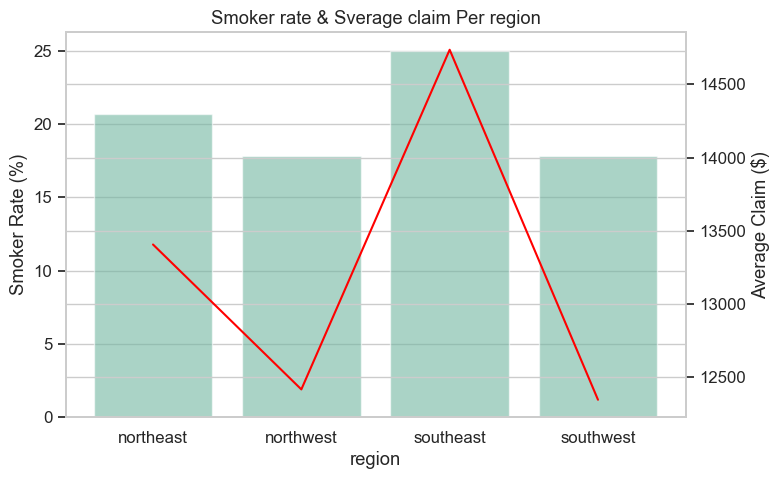

In [34]:
fig, ax1=plt.subplots(figsize=(8,5))
sns.barplot(data=region_stats,x='region',y='smoker_rate',ax=ax1,alpha = 0.6)
ax2 = ax1.twinx()
sns.lineplot(data = region_stats,x='region',y= "mean_claim",ax=ax2,color='red',markers='*')
ax1.set_ylabel("Smoker Rate (%)")
ax2.set_ylabel("Average Claim ($)")
plt.title("Smoker rate & Sverage claim Per region")

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib

In [36]:
data.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges',
       'age_group', 'bmi_category'],
      dtype='object')

In [37]:
x =data[['age','sex','bmi','smoker','children']]
y = data['charges']

In [38]:
x

,age,sex,bmi,smoker,children
0,19,female,27.90,yes,0
1,18,male,33.77,no,1
2,28,male,33.00,no,3
3,33,male,22.70,no,0
4,32,male,28.88,no,0
...,...,...,...,...,...
1333,50,male,30.97,no,3
1334,18,female,31.92,no,0
1335,18,female,36.85,no,0
1336,21,female,25.80,no,0


In [39]:
cat_col = ['sex','smoker']
label_encoders = {}

In [40]:
for col in cat_col:
    le = LabelEncoder()
    x[col] = le.fit_transform(x[col])
    label_encoders[col] = le 

    joblib.dump(le,f"label_encoder_{col}.pkl")

C:\Users\subha\AppData\Local\Temp\ipykernel_23100\3693066876.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = le.fit_transform(x[col])
C:\Users\subha\AppData\Local\Temp\ipykernel_23100\3693066876.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[col] = le.fit_transform(x[col])


In [41]:
label_encoders

{'sex': LabelEncoder(), 'smoker': LabelEncoder()}

In [42]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [43]:
num_col = ['age','bmi','children']

scaler = StandardScaler()

In [44]:
x_train[num_col] = scaler.fit_transform(x_train[num_col])
x_test[num_col] = scaler.fit_transform(x_test[num_col])

In [45]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [46]:
print(x_train.shape,y_train.shape)

(1070, 5) (1070,)


In [47]:
import numpy as np 
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import GridSearchCV , cross_val_score
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [48]:
def evaluate_model(model,x_train,x_test,y_train,y_test):
    y_pred = model.predict(x_test)
    r2 = r2_score(y_test,y_pred)
    mae = mean_absolute_error(y_test,y_pred)
    rmse = np.sqrt(mean_squared_error(y_test,y_pred))
    return {"R2" : r2, "MAE" : mae, "RMSE" : rmse}


In [49]:
results = {}

In [50]:
lr = LinearRegression()
lr.fit(x_train,y_train)
results["Linear Regression"] = evaluate_model(lr,x_train,x_test,y_train,y_test)
print("Linear Regression model trained")



rf = RandomForestRegressor()

rf_params = {
    "n_estimators":[100,200],
    "max_depth":[None,10,20],
    "min_samples_split":[2,5],
    "min_samples_leaf":[1,2]
}

rf_grid = GridSearchCV(rf,rf_params,cv=3,scoring="r2",n_jobs=-1,verbose=0)
rf_grid.fit(x_train,y_train)

best_rf = rf_grid.best_estimator_
results["Random Forest Regressor"] = evaluate_model(best_rf,x_train,x_test,y_train,y_test)

print("Random Forest Training completed, best parameters: ",rf_grid.best_params_)
best_k = 0
best_score = 0

for k in range(1, 21):
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    score = r2_score(y_test, y_pred)
    
    if score > best_score:
        best_score = score
        best_k = k

print("Best K Value:", best_k)
print("Best R2 Score:", best_score)

# Final Model with Best K
final_model = KNeighborsRegressor(n_neighbors=best_k)
final_model.fit(x_train,y_train)
results["KNeighbors Regressor"]=evaluate_model(final_model,x_train,x_test,y_train,y_test)
# Evaluation
print("\nKNeighbors Regression model training completed with :",best_k," no. of neighbors")

# ---------------- Decision Tree Regressor ----------------

dt = DecisionTreeRegressor()

dt_params = {
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

dt_grid = GridSearchCV(
    dt,
    dt_params,
    cv=3,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(x_train, y_train)

best_dt = dt_grid.best_estimator_

results["Decision Tree Regressor"] = evaluate_model(
    best_dt,
    x_train,
    x_test,
    y_train,
    y_test
)

print("Decision Tree Training completed, best parameters:", dt_grid.best_params_)


Linear Regression model trained
Random Forest Training completed, best parameters:  {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best K Value: 4
Best R2 Score: 0.7725809742919965

KNeighbors Regression model training completed with : 4  no. of neighbors
Decision Tree Training completed, best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}


In [51]:
results

{'Linear Regression': {'R2': 0.7043988812467628,
  'MAE': 4414.398239087178,
  'RMSE': np.float64(6457.887077209262)},
 'Random Forest Regressor': {'R2': 0.8070705421224986,
  'MAE': 2725.655932696979,
  'RMSE': np.float64(5217.190345603491)},
 'KNeighbors Regressor': {'R2': 0.7725809742919965,
  'MAE': 3092.408685266791,
  'RMSE': np.float64(5664.359478486276)},
 'Decision Tree Regressor': {'R2': 0.7151665778663256,
  'MAE': 3147.5819984819473,
  'RMSE': np.float64(6339.17708312248)}}

In [52]:
result_df=pd.DataFrame(results).T.sort_values(by='R2',ascending=False)
result_df

,R2,MAE,RMSE
Random Forest Regressor,0.81,2725.66,5217.19
KNeighbors Regressor,0.77,3092.41,5664.36
Decision Tree Regressor,0.72,3147.58,6339.18
Linear Regression,0.70,4414.40,6457.89


In [53]:
models = {
    "Linear Regression":lr,
    "Decision Tree Regressor" : best_dt,
    "KNeighbors Regressor" : final_model,
    "Random Forest Regressor" : best_rf
}

In [54]:
best_r2 = result_df["R2"].max()

In [55]:
best_r2

np.float64(0.8070705421224986)

In [56]:
top_model = result_df[result_df["R2"] == best_r2]
top_model

,R2,MAE,RMSE
Random Forest Regressor,0.81,2725.66,5217.19


In [57]:
best_model = models[top_model.index[0]]

In [58]:
best_model

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [59]:
joblib.dump(best_model,"best_model.pkl")
print(f"Best Model Selected : {top_model.index[0]}")

Best Model Selected : Random Forest Regressor
